# 06 · Randomized benchmarking of the qutrit gate set (`ibm_lagos`, summer 2023)

With the 216 Cliffords decomposed into pulses (notebook 05) and the frame phases α, β, γ tracked (notebook 07), the shop ran
single-qutrit **randomized benchmarking** (RB) and **interleaved RB** of the Hadamard on `ibm_lagos` qubit 0 (Jun–Aug 2023,
`rb/RMB.ipynb`, `experiment/interleaved_rb/`). The raw job data (50 jobs × 97 sequence lengths × 20 000 shots) were kept as csv
files that did not survive; what survives are the averaged survival curves printed in the notebooks, recovered here, and the
code, rebuilt in `pulseshop.clifford`.

Survival of |0⟩ after $m$ random Cliffords plus the inverting one: $P_0(m) = A\,p^m + B$; the average error per Clifford for a
qutrit is $r = (1-p)(d-1)/d = \tfrac{2}{3}(1-p)$ (Morvan 2021). Interleaving a fixed gate $G$ after every random Clifford gives
$p_G$ and the error of $G$ alone, $r_G = \tfrac23(1 - p_G/p)$.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
from pulseshop import clifford, su3, fitting, io, qutrit as Q
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Building RB sequences

In [2]:
C3 = clifford.generate_clifford3()
inv = clifford.inverse_table(C3)
params = su3.decompose_all(C3)
rng = np.random.default_rng(2023)
for m in [1, 5, 20]:
    seq = clifford.rb_sequence(m, C3, inv, rng)
    print(f"m = {m:2d}: {seq} -> returns to |0>: {clifford.check_is_inverse(seq, C3)}")
seq = clifford.interleaved_rb_sequence(0, 4, C3, inv, rng)
print("interleaved Hadamard (index 0):", seq, "->", clifford.check_is_inverse(seq, C3))

m =  1: [102 117] -> returns to |0>: True
m =  5: [19 33 47 64 24 79] -> returns to |0>: True
m = 20: [129  95  55 150  13 117  55 164  50 126  91 193  25  32  42 108  71 183
  52  39 150] -> returns to |0>: True
interleaved Hadamard (index 0): [111   0 132   0   8   0  61   0 150] -> True


Every sequence of $m$ Cliffords needs $3m + 3$ pulses with the decomposition of notebook 05; at $m = 97$ that is 294 pulses of 144–160 dt,
≈ 22 µs, comparable to the $T_1$ of the device — the reason the long run (lengths 1…291) decays to a floor.

## 2. A noisy simulation: what a coherent error does to the curve

Replace each 1–2 rotation by one with an over-rotation ε and a phase error δ (notebook 04's heuristic model) and watch the
survival probability decay. This is the numerical twin of the experiment and a check of the fitting formula.

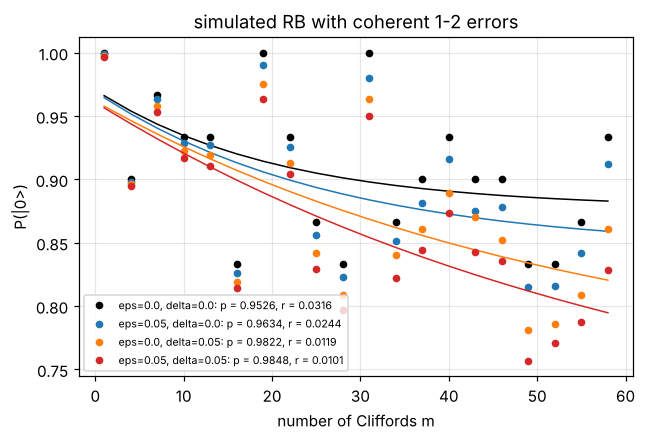

In [3]:
def noisy_clifford(idx, eps, delta):
    t1, t2, t3, p1, p2, p3, p4, p5, p6 = params[idx]
    R12n = Q.Z12(p2) @ Q.RGM12(t2, eps * t2 / (np.pi / 2), delta) @ Q.Z12(-p2)
    return Q.U_d(p6, p5, p4) @ Q.R01(t3, p3) @ R12n @ Q.R01(t1, p1)

def survival(eps, delta, lengths, n_seq=30, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    out = []
    for m in lengths:
        acc = 0.0
        for _ in range(n_seq):
            seq = clifford.rb_sequence(m, C3, inv, rng)
            U = np.eye(3, dtype=complex)
            for idx in seq:
                U = noisy_clifford(idx, eps, delta) @ U
            acc += Q.populations(U @ Q.ket0)[0]
        out.append(acc / n_seq)
    return np.array(out)

lengths = np.arange(1, 60, 3)
fig, ax = plt.subplots(figsize=(6.5, 4))
for eps, delta, c in [(0.0, 0.0, "k"), (0.05, 0.0, "C0"), (0.0, 0.05, "C1"), (0.05, 0.05, "C3")]:
    y = survival(eps, delta, lengths)
    pars, yfit, _ = fitting.fit_function(lengths, y, fitting.rb_decay, [0.6, 0.33, 0.98])
    ax.plot(lengths, y, "o", ms=4, color=c, label=f"eps={eps}, delta={delta}: p = {pars[2]:.4f}, r = {fitting.rb_error_per_clifford(pars[2]):.4f}")
    ax.plot(lengths, yfit, "-", color=c, lw=1)
ax.set(xlabel="number of Cliffords m", ylabel="P(|0>)", title="simulated RB with coherent 1-2 errors"); ax.legend(fontsize=7)
io.save_fig(fig, "06_rb_simulation_coherent_errors")

## 3. The measured curves (recovered from the notebook outputs)

* `rb_lagos_2023-08_avg_p0_lengths_1_to_97_49jobs.npy` — standard RB, average over 49 jobs, lengths 1…97 (`rb/RMB.ipynb`);
* `irb_hadamard_lagos_2023-08-29_avg_p0_lengths_1_to_97.npy` — interleaved RB of the Hadamard, 50 jobs, 29 Aug 2023.

(The longer run to length 291 that gave $p = 0.9832$, "$F = 98.32$ %", was not printed in full and could not be recovered.)

RB:  p = 0.9714  ->  error per Clifford r = 0.0190  (notebook: p = 0.96383)
IRB: p_H = 0.9638  (notebook: 0.96419)
Hadamard error estimate r_H = 2/3 (1 - p_H/p) = +0.0052


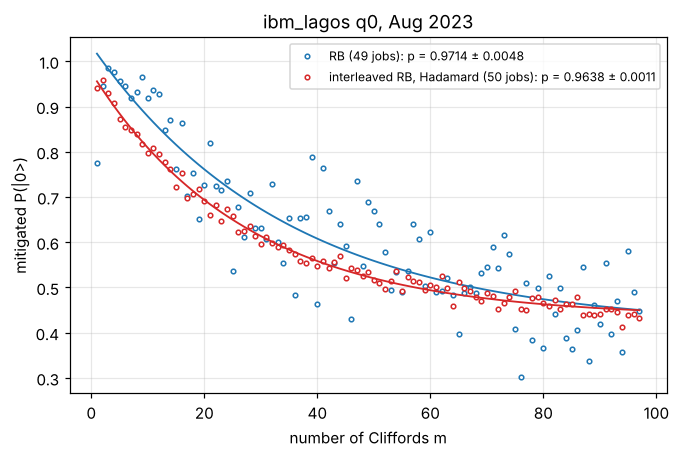

In [4]:
m = np.arange(1, 98)
rb = io.load_npy("shop_2023_legacy/rb", "rb_lagos_2023-08_avg_p0_lengths_1_to_97_49jobs.npy")
irb = io.load_npy("shop_2023_legacy/rb", "irb_hadamard_lagos_2023-08-29_avg_p0_lengths_1_to_97.npy")
fits = {}
fig, ax = plt.subplots(figsize=(7, 4.2))
for y, lab, c in [(rb, "RB (49 jobs)", "C0"), (irb, "interleaved RB, Hadamard (50 jobs)", "C3")]:
    sel = m > 1          # the m = 1 point of the RB curve is anomalous (see below) and is left out of the fit
    pars, yfit, pcov = fitting.fit_function(m[sel], y[sel], fitting.rb_decay, [0.5, 0.5, 0.97])
    yfit = fitting.rb_decay(m, *pars)
    fits[lab] = pars
    ax.plot(m, y, "o", ms=3, mfc="white", color=c, label=f"{lab}: p = {pars[2]:.4f} ± {np.sqrt(pcov[2,2]):.4f}")
    ax.plot(m, yfit, "-", color=c, lw=1.2)
ax.set(xlabel="number of Cliffords m", ylabel="mitigated P(|0>)", title="ibm_lagos q0, Aug 2023"); ax.legend(fontsize=8)
io.save_fig(fig, "06_rb_irb_lagos_2023")

p_rb = fits["RB (49 jobs)"][2]; p_irb = fits["interleaved RB, Hadamard (50 jobs)"][2]
print(f"RB:  p = {p_rb:.4f}  ->  error per Clifford r = {fitting.rb_error_per_clifford(p_rb):.4f}  (notebook: p = 0.96383)")
print(f"IRB: p_H = {p_irb:.4f}  (notebook: 0.96419)")
print(f"Hadamard error estimate r_H = 2/3 (1 - p_H/p) = {2/3*(1 - p_irb/p_rb):+.4f}")

The reference curve gives $p \approx 0.97$, i.e. $r \approx 1.9$ % per Clifford (the notebook's own fit of a slightly different average,
1…98, gave 0.9638, r = 2.4 %; the long run to 291 Cliffords gave 0.9832, r = 1.1 %), and the interleaved Hadamard $p_H = 0.964$. The Hadamard's own
error, $r_H = \tfrac23(1 - p_H/p) \approx 0.5$–$0.8$ %, is at the limit of what the two curves can separate: a Clifford *is* three
pulses of the same kind as the Hadamard, so the two decays are nearly the same. The per-Clifford error is the number the shop set out
to beat with the shorter, DRAG-corrected pulses of 2024–25 (notebooks 03–04). The anomalous first point of the RB curve
($P_0(1) = 0.77$) is the length-1 sequence, where the inverting Clifford of a random Clifford is the same gate again for the ten
self-inverse elements and the readout of |2⟩ dominates; it is excluded from the fit.

## 4. Where the frame phases enter

Before each run the three kicks were fitted from the phase-tracking data of the same day (notebook 07) and fed to
`create_pulse_sequence`: α, β, γ = (0.610, 0.730, 6.243) for the Aug 2023 runs (`constants.PARAMS['lagos_q0_2023-08']`).
Without them, the second pulse of every Clifford would be played in the wrong frame and the survival would decay within a few gates.

In [5]:
from pulseshop import constants as C
fp = C.PARAMS["lagos_q0_2023-08"]["frame_phases"]
seq = clifford.rb_sequence(2, C3, inv, np.random.default_rng(5))
pulses, frames = clifford.pulse_sequence_phases([params[i] for i in seq], **fp)
print("sequence", seq)
for sub, th, ph in pulses:
    print(f"  R{sub}(theta={th:.3f}, phi={ph % (2*np.pi):.3f})")

sequence [144 173 114]
  R01(theta=3.142, phi=0.000)
  R12(theta=3.142, phi=0.610)
  R01(theta=3.142, phi=0.730)
  R01(theta=1.571, phi=2.300)
  R12(theta=1.911, phi=3.361)
  R01(theta=1.571, phi=1.459)
  R01(theta=1.571, phi=2.507)
  R12(theta=1.911, phi=5.588)
  R01(theta=1.571, phi=1.665)
